<a href="https://colab.research.google.com/github/Subash65/App/blob/main/Zeotap_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import datetime

In [12]:
customers = pd.read_csv('Customers.csv')
transactions = pd.read_csv('Transactions.csv')
products = pd.read_csv('Products.csv')

In [13]:
# Merge datasets on CustomerID
customer_transactions = pd.merge(customers, transactions, on='CustomerID')

In [14]:
# Aggregate transaction data by CustomerID
customer_summary = customer_transactions.groupby('CustomerID').agg(
    TotalSpent=('TotalValue', 'sum'),
    TransactionFrequency=('TransactionID', 'count'),
    Recency=('TransactionDate', lambda x: (pd.to_datetime('today') - pd.to_datetime(x).max()).days),
    AvgTransactionValue=('TotalValue', 'mean')
).reset_index()

In [15]:
# Add AccountAge feature
customer_summary['AccountAge'] = (pd.to_datetime('today') - pd.to_datetime(customers['SignupDate'])).dt.days


In [16]:
# Merge customer profile features with aggregated transaction features
customer_data = pd.merge(customers[['CustomerID', 'Region']], customer_summary, on='CustomerID')

In [17]:
# One-hot encoding of categorical feature 'Region'
customer_data = pd.get_dummies(customer_data, columns=['Region'], drop_first=True)

In [20]:
# Features for clustering (excluding 'CustomerID')
features = customer_data.drop(['CustomerID'], axis=1)


In [21]:
# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [22]:
# Determine the optimal number of clusters (between 2 and 10)
# Elbow method for K-Means
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

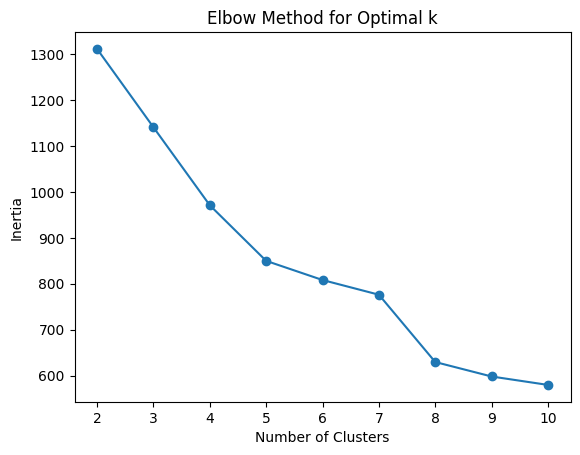

In [23]:
# Plot inertia to visualize the elbow
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()



In [24]:
# Based on the elbow plot, choose the optimal number of clusters (e.g., k = 4)
k = 4  # You can adjust this based on the elbow plot

In [25]:
# Fit K-Means with the chosen k
kmeans = KMeans(n_clusters=k, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(scaled_features)

In [26]:
# Calculate clustering metrics
db_index = davies_bouldin_score(scaled_features, customer_data['Cluster'])
silhouette = silhouette_score(scaled_features, customer_data['Cluster'])

In [27]:
# Output clustering metrics
print(f'Davies-Bouldin Index: {db_index}')
print(f'Silhouette Score: {silhouette}')


Davies-Bouldin Index: 1.5794235034176265
Silhouette Score: 0.22785550173852992


In [28]:
# Visualize the clusters using PCA (2D projection)
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

In [29]:
# Create a dataframe with PCA components and cluster labels
pca_df = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = customer_data['Cluster']

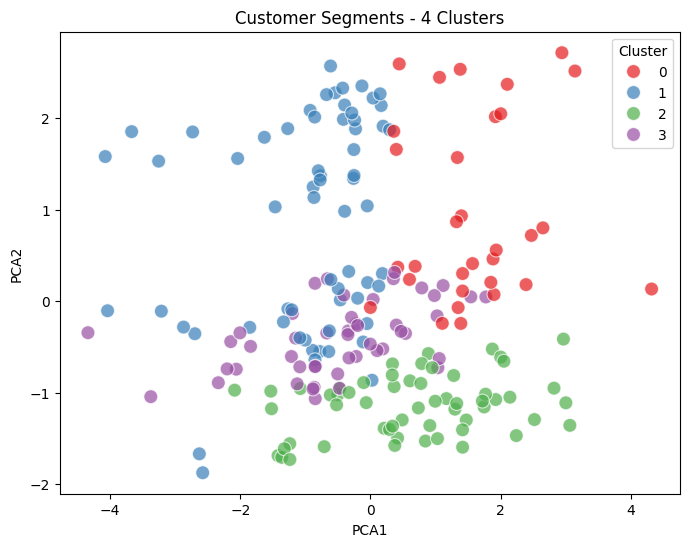

In [30]:
# Plot the clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=pca_df, s=100, alpha=0.7)
plt.title(f'Customer Segments - {k} Clusters')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster')
plt.show()

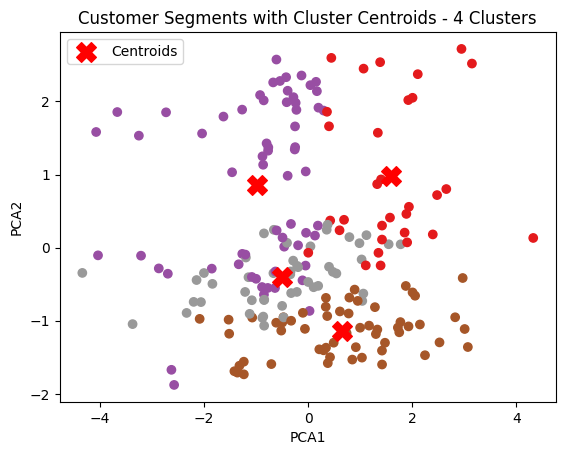

In [31]:
# Visualize cluster centers on the PCA plot
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=customer_data['Cluster'], cmap='Set1')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'Customer Segments with Cluster Centroids - {k} Clusters')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

In [32]:
# Report summary
print(f"\nClustering Report:")
print(f"Number of Clusters: {k}")
print(f"DB Index: {db_index}")
print(f"Silhouette Score: {silhouette}")


Clustering Report:
Number of Clusters: 4
DB Index: 1.5794235034176265
Silhouette Score: 0.22785550173852992


In [33]:
# Save the customer data with cluster labels to a new CSV
customer_data.to_csv('segmented_customers.csv', index=False)